# 실습 5-2 : SHAP Value

#### **<실습 내용>**

1. SHAP - 회귀 모델 (Regression)
- TreeExplainer를 사용한 SHAP 분석
- Summary Plot / Force Plot / Dependence Plot

3. SHAP - 분류 모델 (Classification)
- TreeExplainer를 사용한 SHAP 분석
- Summary Plot / Force Plot / Dependence Plot

## 분석 준비

### 주요 라이브러리 호출

In [2]:
!pip install shap

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, f1_score
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

import shap

/Users/seorincho/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 1) SHAP - 회귀 모델

In [4]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 1-1) 데이터 및 모델 준비

In [5]:
Regression = pd.read_csv("dataset/day5-2_reg_data.csv")
Regression

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X50,X51,X52,X53,X54,X55,X56,X57,X58,y
0,0.40420,0.39615,0.34470,0.39535,0.44180,0.38830,0.36245,0.34480,0.32475,0.38020,...,0.39200,0.34985,0.37980,0.42355,0.38990,0.40890,0.41720,0.37765,0.36190,48.272178
1,0.47115,0.35280,0.29120,0.30190,0.54875,0.40430,0.42125,0.32620,0.35280,0.43115,...,0.32080,0.35185,0.35570,0.38400,0.44375,0.25945,0.55030,0.43205,0.31395,49.767621
2,0.31185,0.35220,0.41940,0.38370,0.30015,0.32555,0.39790,0.44730,0.55625,0.60885,...,0.36105,0.36230,0.30455,0.26945,0.49770,0.37425,0.27800,0.41980,0.37620,45.512356
3,0.43900,0.38300,0.38830,0.33920,0.40740,0.40650,0.45455,0.40565,0.41915,0.33565,...,0.33715,0.46605,0.45040,0.37150,0.37625,0.28595,0.45195,0.40570,0.39885,55.646432
4,0.38005,0.42835,0.53105,0.39145,0.31755,0.40365,0.33230,0.48530,0.44295,0.37615,...,0.43555,0.30330,0.26910,0.35155,0.42230,0.43660,0.35875,0.43605,0.46260,47.703096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,0.40675,0.37110,0.29385,0.37125,0.43345,0.32380,0.40365,0.32200,0.35655,0.50940,...,0.31965,0.32385,0.37480,0.37240,0.46065,0.33660,0.40075,0.37875,0.30040,44.683854
237,0.37940,0.36660,0.39205,0.42100,0.37860,0.42690,0.39580,0.39240,0.39080,0.35705,...,0.43260,0.40485,0.36410,0.45070,0.37270,0.45270,0.36685,0.39055,0.40395,47.907255
238,0.35150,0.35285,0.24365,0.40190,0.50055,0.37125,0.36820,0.28830,0.34130,0.48590,...,0.38300,0.38705,0.41305,0.40750,0.39510,0.40895,0.40825,0.35865,0.30240,45.900853
239,0.30580,0.46180,0.50870,0.43220,0.38695,0.43260,0.24155,0.45805,0.38565,0.29875,...,0.51305,0.36490,0.35580,0.36160,0.31170,0.53040,0.36960,0.38475,0.49090,51.418961


In [6]:
X_reg = Regression.drop(["y"], axis=1) # 입력변수
Y_reg = Regression["y"] # 출력변수

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(X_reg, Y_reg, test_size=0.2, random_state=42) # 학습/테스트 데이터 분할

In [7]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0) # RandomForest로 모델 학습
rf_reg.fit(X_train_reg, Y_train_reg)
Y_pred_reg = rf_reg.predict(X_test_reg)
get_regscore(Y_test_reg, Y_pred_reg)

MSE       : 6.598
RMSE      : 2.569
MAE       : 1.991
R-squared : 0.558


### 2-2) SHAP 분석

In [8]:
# rf_reg 모델을 해석하기 위한 SHAP 설명자 생성
explainer_reg = shap.TreeExplainer(rf_reg)

# 학습 데이터(X_train_reg)에 대한 SHAP value 계산
# 각 feature가 예측값에 기여하는 정도를 나타냄
shap_values_reg = explainer_reg.shap_values(X_train_reg)

#### Summary Plot (Bar)
- 막대가 길수록 예측에 영향을 많이 주는 변수라는 뜻임

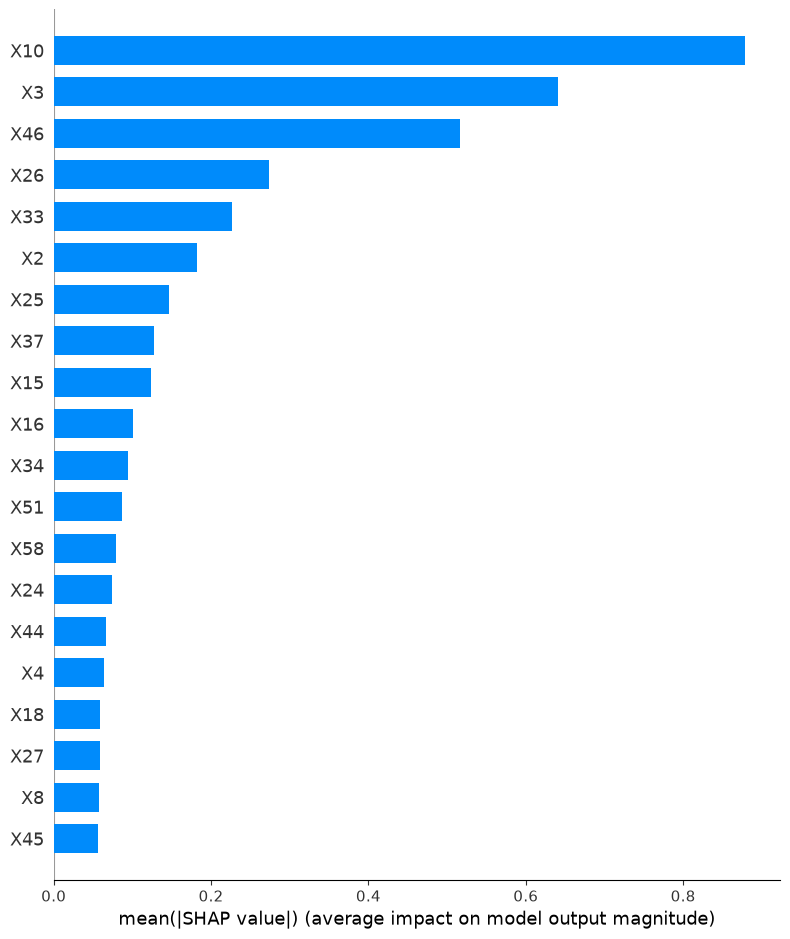

In [9]:
shap.summary_plot(shap_values_reg, X_train_reg, plot_type='bar')

#### Summary Plot (Scatter)
- 오른쪽에 점이 몰려있으면 예측값을 올리는 변수, 왼쪽에 몰려있으면 예측값을 낮추는 변수임

> - 빨간색: 높은 변수 값
> - 파란색: 낮은 변수 값

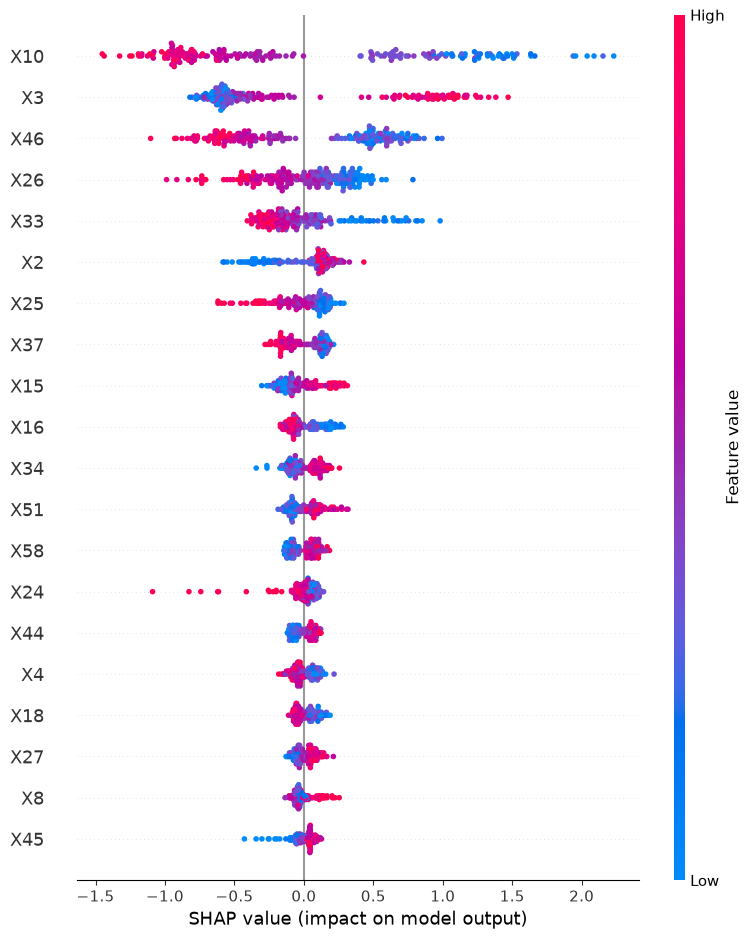

In [10]:
shap.summary_plot(shap_values_reg, X_train_reg)

#### Force Plot (개별 데이터)
- 데이터 하나를 뽑아서 어떤 변수가 예측값을 올렸고 내렸는지 화살표로 보여주는 그래프임

In [11]:
base_value_reg = explainer_reg.expected_value
print(base_value_reg)

[49.74460342]


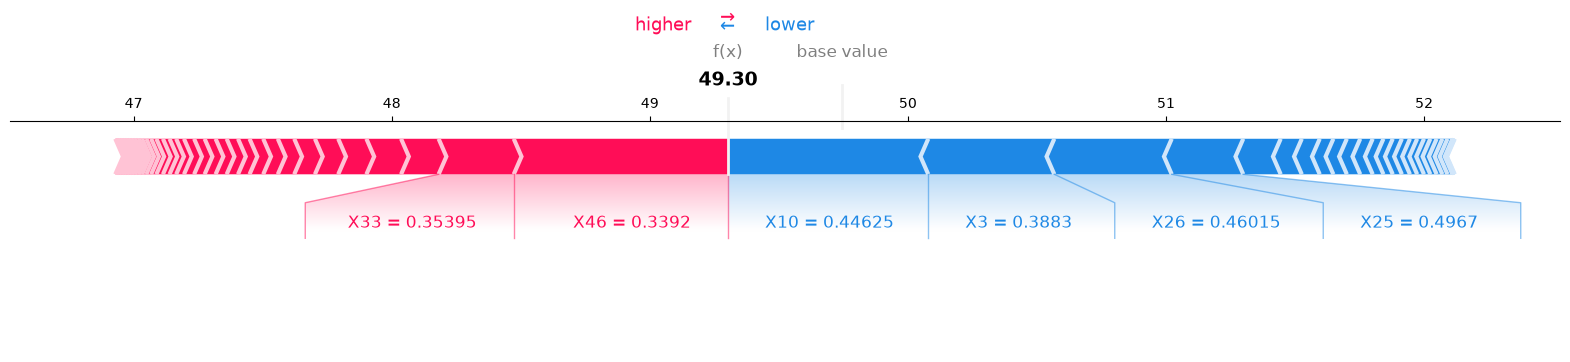

In [12]:
# 첫 번째 데이터(index 0)의 예측 결과를 force plot으로 시각화
# expected_value: 전체 데이터의 평균 예측값 (기준선)
# shap_values_reg[0]: 이 데이터의 각 feature별 SHAP value 
# X_train_reg.iloc[0]: 실제 feature 값들 (그래프에 표시용)

shap.force_plot(
    explainer_reg.expected_value,
    shap_values_reg[0],
    X_train_reg.iloc[0],
    matplotlib=True
)

#### Dependence Plot
- 변수 값이 변할 때 SHAP 값(영향력)이 같이 어떻게 움직이는지 보여주는 그래프임

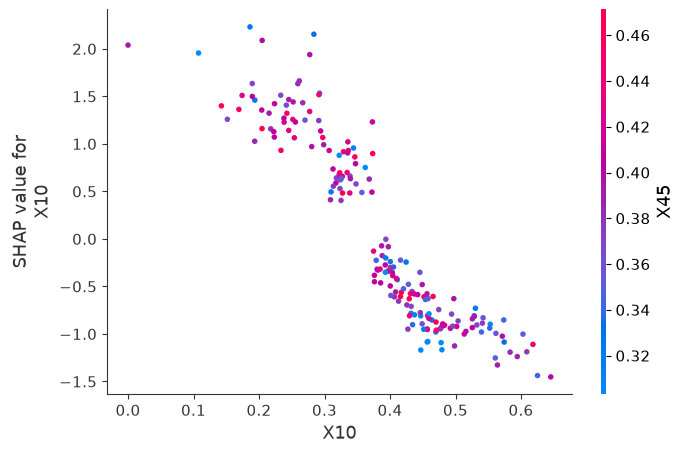

In [13]:
# "X10" feature 값에 따라 SHAP value가 어떻게 변하는지 시각화
# x축: X10의 실제 값, y축: X10의 SHAP value (예측에 미친 영향)
# 자동으로 X10과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X10",
    shap_values_reg,
    X_train_reg
)

---

## 3) SHAP - 분류 모델

In [14]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 3-1) 데이터 및 모델 준비

In [15]:
Classification = pd.read_csv("dataset/day5-2_cls_data.csv")
Classification

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X466,X467,X468,X469,X470,X471,X472,X473,X474,Y
0,0.457896,0.530189,0.276976,0.359864,0.193059,0.322190,0.706897,0.553781,0.653894,0.375204,...,0.246376,0.711806,0.008532,0.013672,0.008467,0.402240,0.238811,0.274876,0.210238,-1
1,0.607100,0.341478,0.518992,0.395300,0.042071,0.469654,0.750000,0.542031,0.447466,0.189233,...,0.523785,0.760417,0.030930,0.033203,0.029759,0.210356,0.309339,0.328358,0.439175,-1
2,0.360781,0.369653,0.341039,0.021697,0.181737,0.528684,0.491379,0.516722,0.300371,0.376835,...,0.185769,0.659722,0.005333,0.003906,0.005311,0.381877,0.208171,0.208955,0.155761,-1
3,0.460910,0.413500,0.535685,0.302794,0.242326,0.408966,0.646552,0.561615,0.415328,0.313214,...,0.246376,0.000000,1.000000,1.000000,1.000000,0.381877,0.208171,0.208955,0.155761,-1
4,0.263068,0.279821,0.535685,0.302794,0.242326,0.408966,0.646552,0.638747,0.660074,0.520392,...,0.110711,0.517361,0.023677,0.022461,0.023447,0.608414,0.212062,0.268657,0.092827,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,0.360022,0.396033,0.382803,0.070771,0.143308,0.920884,0.586207,0.636336,0.337454,0.432300,...,0.000000,0.597222,0.016212,0.013672,0.015997,0.045307,0.147860,0.171642,0.000000,1
250,0.508628,0.437628,0.192378,0.061866,0.168425,0.481919,0.715517,0.270563,0.407911,0.336052,...,0.132582,0.975694,0.017065,0.015625,0.016114,0.543689,0.227626,0.320896,0.111165,1
251,0.275930,0.364365,0.302236,0.376615,0.485135,0.627270,0.594828,0.435673,0.420272,0.367047,...,0.246376,0.586806,0.008532,0.015625,0.008613,0.343042,0.151751,0.164179,0.143012,1
252,0.785179,0.271804,0.400189,0.457851,0.229526,0.244320,0.396552,0.875565,0.110012,0.337684,...,0.221768,0.767361,0.024317,0.019531,0.023461,0.509709,0.398833,0.440299,0.185945,1


In [16]:
X_cls = Classification.drop(["Y"], axis=1) # 입력변수
Y_cls = Classification["Y"] # 출력변수

X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.2, random_state=123, stratify=Y_cls)

rf_cls = RandomForestClassifier(n_estimators=100, random_state=0)
rf_cls.fit(X_train_cls, Y_train_cls)
Y_pred_cls = rf_cls.predict(X_test_cls)
get_classscore(Y_test_cls, Y_pred_cls)

Accuracy  : 0.863
Precision : 0.938
Recall    : 0.714
F1-score  : 0.811

혼동행렬
[[29  1]
 [ 6 15]]


### 3-2) SHAP 분석

In [17]:
explainer_cls = shap.TreeExplainer(rf_cls)
shap_values_cls = explainer_cls.shap_values(X_train_cls)

#### Summary Plot (Bar)

> 분류 모델의 경우 `shap_values_cls`는 (샘플 수, 변수 수, 클래스 수) 형태의 3차원 배열임
> - `shap_values_cls[:, :, 0]`: 클래스 -1에 대한 SHAP
> - `shap_values_cls[:, :, 1]`: 클래스 1에 대한 SHAP

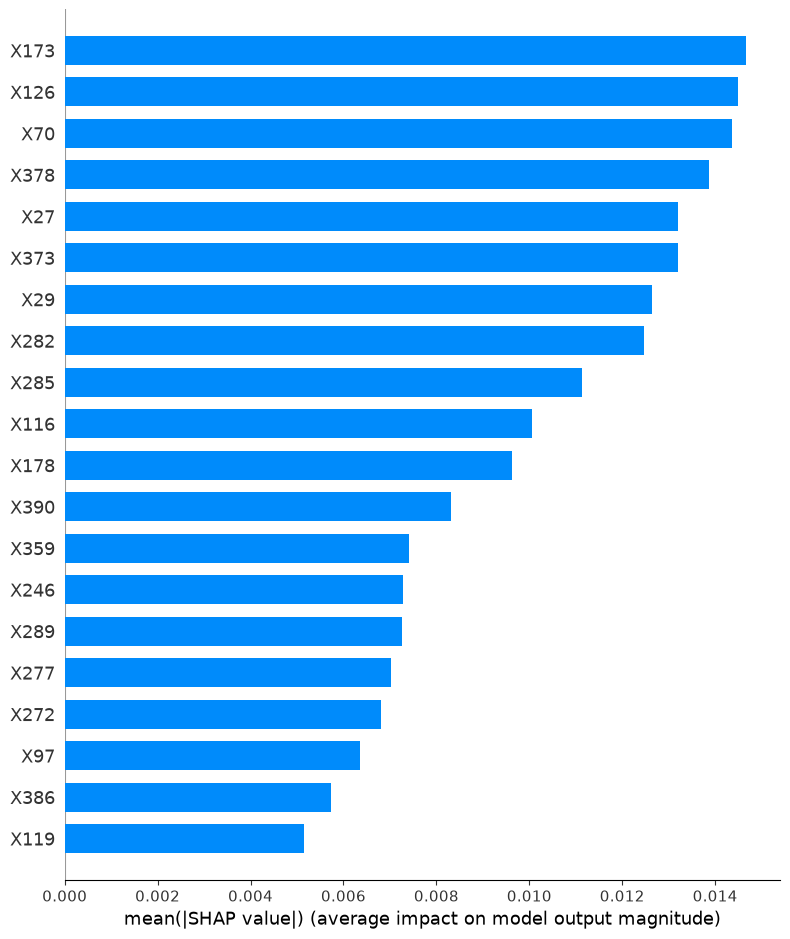

In [18]:
shap.summary_plot(shap_values_cls[:, :, 0], X_train_cls, plot_type='bar')  # 클래스 -1 기준

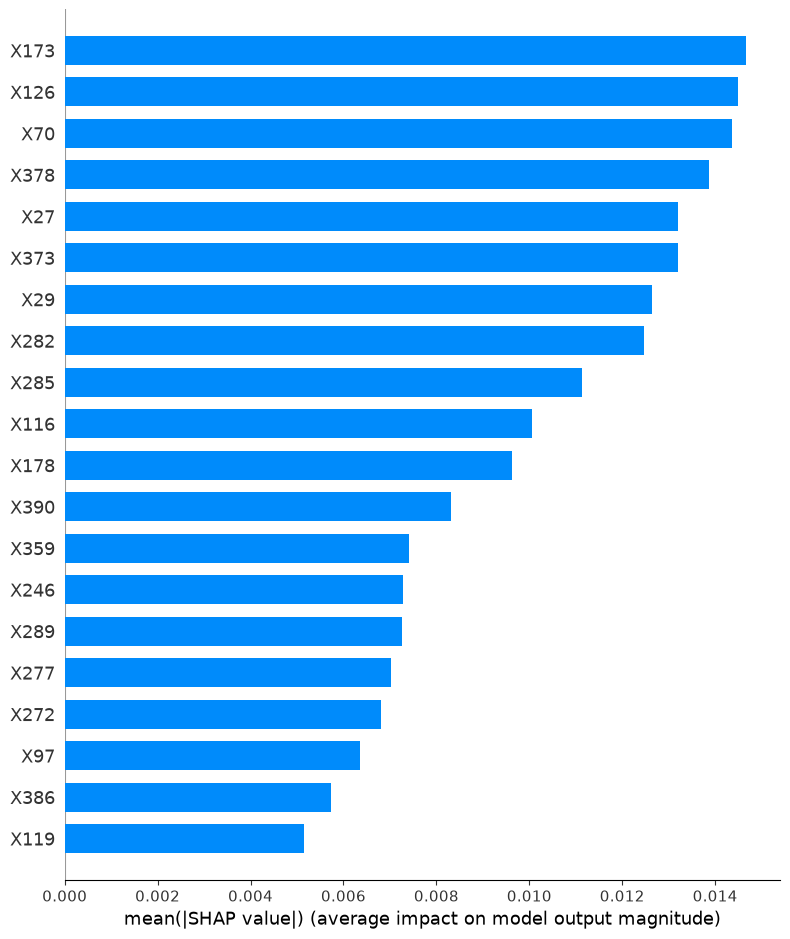

In [19]:
shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls, plot_type='bar')  # 클래스 1 기준

#### Summary Plot (Scatter) - 클래스별

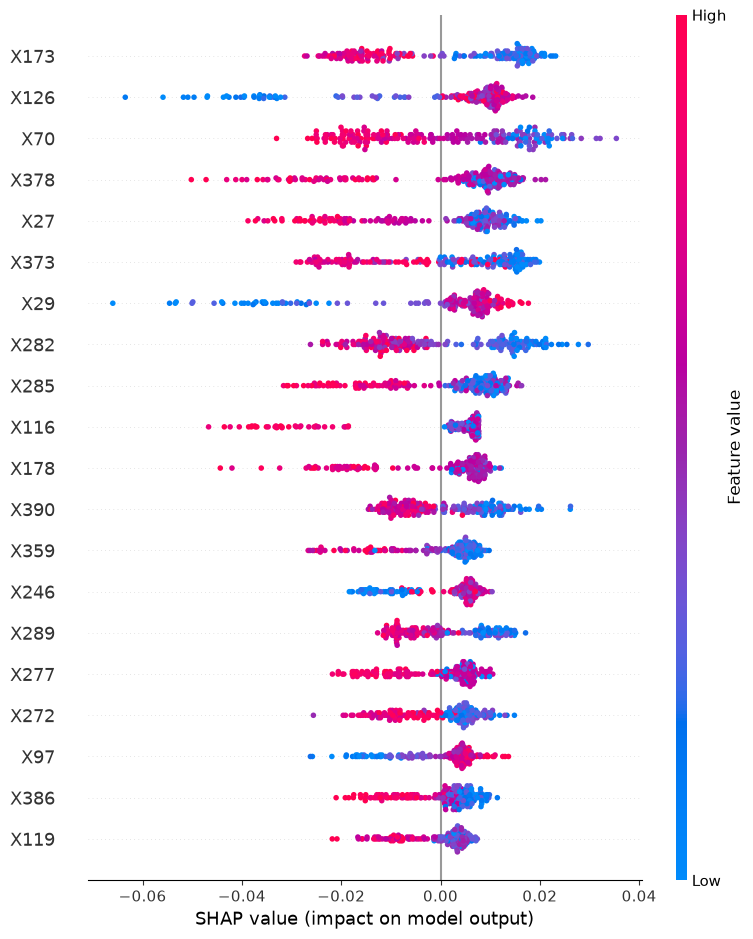

In [20]:
shap.summary_plot(shap_values_cls[:, :, 0], X_train_cls) # 클래스 = -1

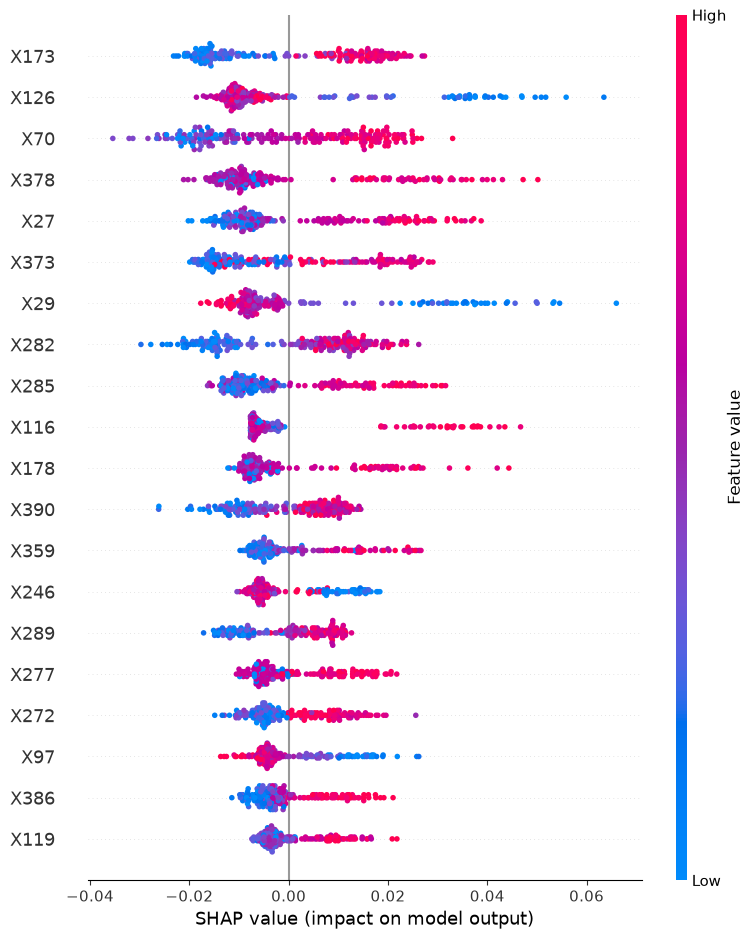

In [21]:
# 변수 중요도 순서는 같은데 부호가 반대 방향임

shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls) # 클래스 = 1

#### Force Plot (개별 데이터)

In [23]:
# 15번 데이터의 실제(정답) 클래스 확인
Y_train_cls.iloc[15]

np.int64(-1)

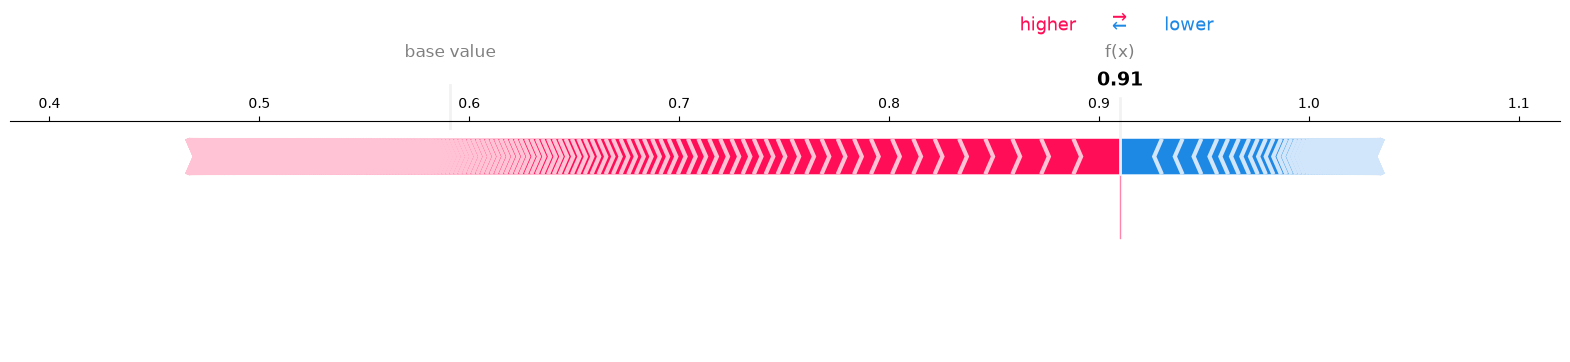

In [24]:
# 15번 데이터를 클래스 -1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[0]: 클래스 -1에 대한 기준값(base value)
# shap_values_cls[15, :, 0]: 15번 데이터의, 클래스 -1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[15]: 15번 데이터의 실제 feature 값들 

shap.force_plot(
    explainer_cls.expected_value[0],
    shap_values_cls[15, :, 0],
    X_train_cls.iloc[15],
    matplotlib=True
)

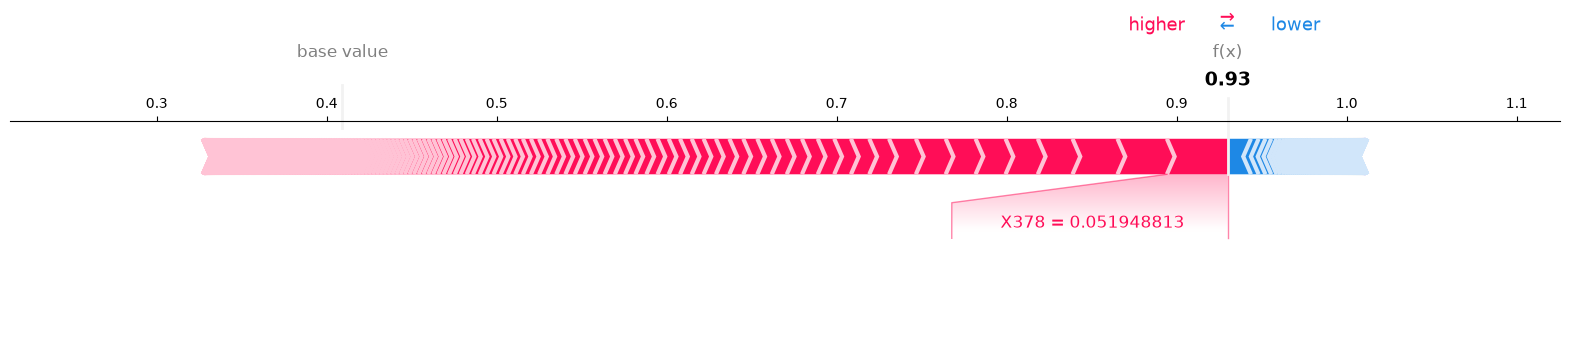

In [25]:
# 40번 데이터를 클래스 1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[1]: 클래스 1에 대한 기준값(base value)
# shap_values_cls[40, :, 1]: 40번 데이터의, 클래스 1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[40]: 40번 데이터의 실제 feature 값들

shap.force_plot(
    explainer_cls.expected_value[1],
    shap_values_cls[40, :, 1],
    X_train_cls.iloc[40],
    matplotlib=True
)

#### Dependence Plot

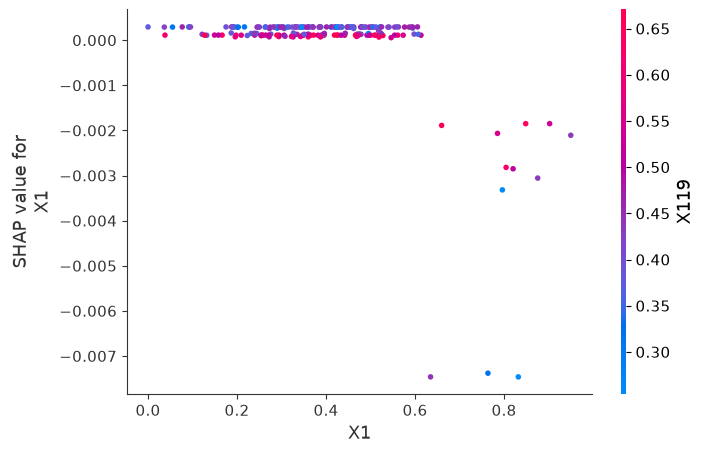

In [26]:
# "X1" feature 값에 따라, 클래스 -1에 대한 SHAP value가 어떻게 변하는지 시각화
# x축: X1의 실제 값, y축: X1의 클래스 -1 기준 SHAP value (예측에 미친 영향)
# 자동으로 X1과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X1",
    shap_values_cls[:, :, 0],
    X_train_cls
)

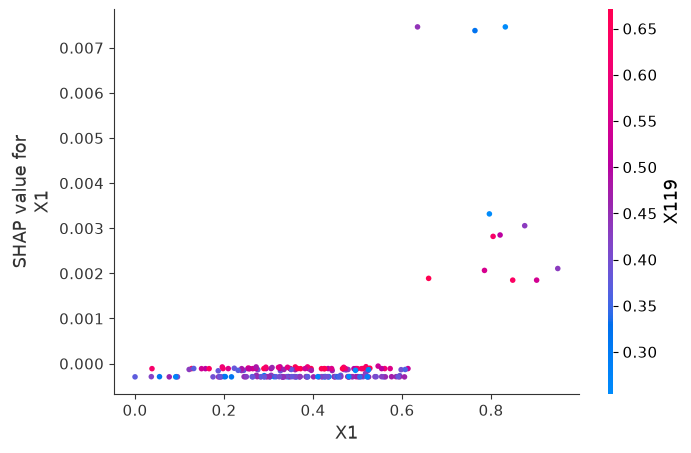

In [27]:
# "X1" feature 값에 따라, 클래스 1에 대한 SHAP value가 어떻게 변하는지 시각화
# x축: X1의 실제 값, y축: X1의 클래스 1 기준 SHAP value (예측에 미친 영향)
# 자동으로 X1과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X1",
    shap_values_cls[:, :, 1],
    X_train_cls
)

---

## 4) Vibe Coding 실습

**[과제 1]** 

지수는 Random Forest의 Feature Importance와 SHAP Value가 모두 변수의 중요도를 설명하는 방법이라는 것을 배웠습니다.

AI와 함께 Random Forest (회귀/분류)의 feature_importances_와 SHAP Summary Plot 결과를 비교해 보세요.

두 방법에서 중요하게 평가된 변수가 얼마나 비슷한지 확인하고 순위가 다른 변수는 왜 차이가 발생했는지 AI와 토의하여 해석해 보세요.

===== 회귀(Regression) =====
Spearman 순위상관계수 : 0.950  (1에 가까울수록 두 방법의 순위가 유사)
Top-5 공통 변수 : 5/5  ->  ['X10', 'X26', 'X3', 'X33', 'X46']
Top-10 공통 변수 : 9/10  ->  ['X10', 'X15', 'X2', 'X25', 'X26', 'X3', 'X33', 'X37', 'X46']

[ RF 기준 상위 변수 순위 비교 ]
feature  RF_importance  RF_rank  SHAP_importance  SHAP_rank  rank_diff
    X10       0.193025        1         0.879081          1          0
     X3       0.141376        2         0.640705          2          0
    X46       0.089514        3         0.516354          3          0
    X26       0.050647        4         0.273539          4          0
    X33       0.034812        5         0.226896          5          0
     X2       0.033480        6         0.181888          6          0
    X25       0.028282        7         0.146616          7          0
    X37       0.026450        8         0.127244          8          0
    X15       0.022193        9         0.124075          9          0
    X58       0.015704       10         0.0795

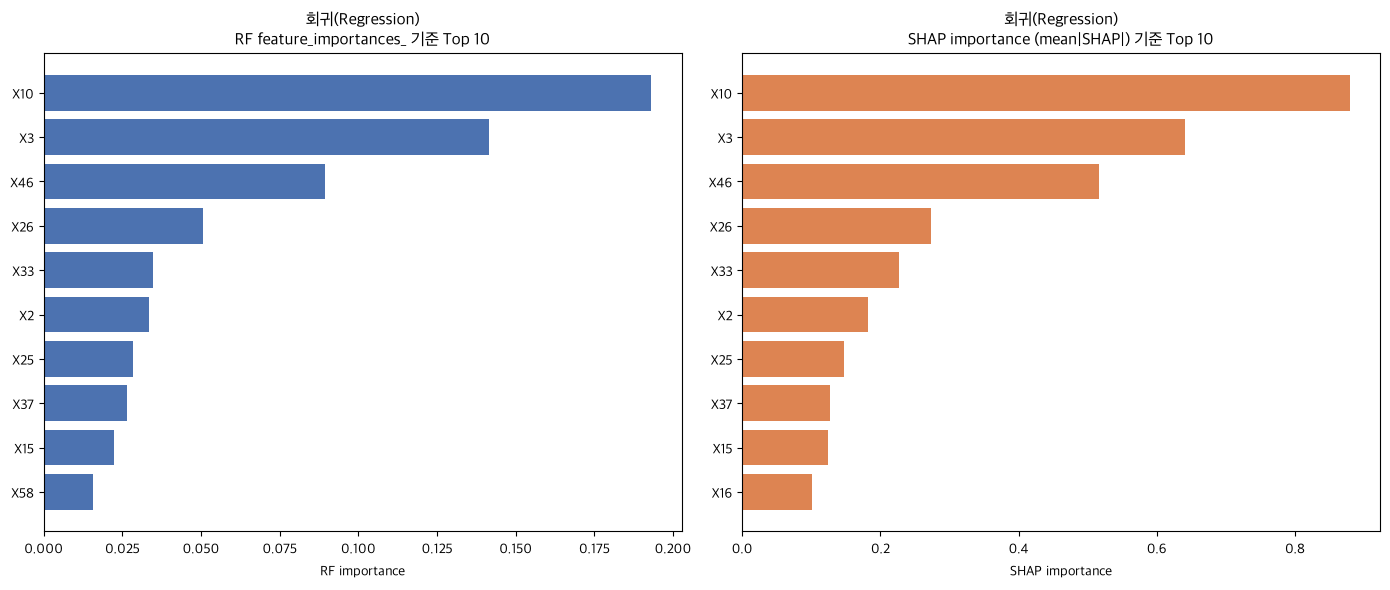

===== 분류(Classification, class=1) =====
Spearman 순위상관계수 : 0.963  (1에 가까울수록 두 방법의 순위가 유사)
Top-5 공통 변수 : 3/5  ->  ['X126', 'X378', 'X70']
Top-10 공통 변수 : 9/10  ->  ['X126', 'X173', 'X27', 'X282', 'X285', 'X29', 'X373', 'X378', 'X70']

[ RF 기준 상위 변수 순위 비교 ]
feature  RF_importance  RF_rank  SHAP_importance  SHAP_rank  rank_diff
   X373       0.024285        1         0.013201          6          5
   X126       0.022421        2         0.014494          2          0
    X70       0.021257        3         0.014354          3          0
    X29       0.021031        4         0.012635          7          3
   X378       0.019221        5         0.013869          4          1
    X27       0.018447        6         0.013207          5          1
   X282       0.017265        7         0.012474          8          1
   X173       0.016975        8         0.014662          1          7
   X277       0.014767        9         0.007017         16          7
   X285       0.014313       10     

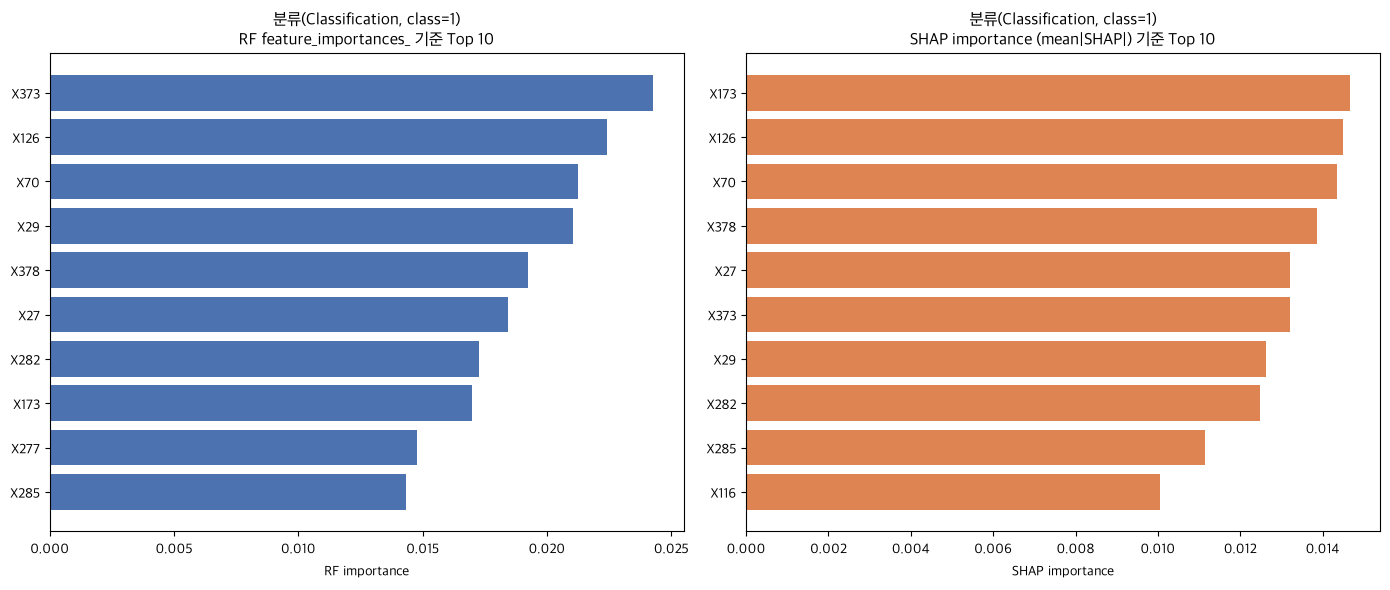

In [29]:
import os
import matplotlib.font_manager as fm
from matplotlib import rcParams
from scipy.stats import spearmanr

# ===== 한글 폰트 설정 (plot 깨짐 방지) =====
FONT_CANDIDATES = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "C:/Windows/Fonts/malgun.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]
FONT_PATH = next((p for p in FONT_CANDIDATES if os.path.exists(p)), None)
if FONT_PATH:
    fm.fontManager.addfont(FONT_PATH)
    KOREAN_FONT = fm.FontProperties(fname=FONT_PATH)
    rcParams["font.family"] = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None
rcParams["axes.unicode_minus"] = False

# Random Forest feature_importances_ 와 SHAP( mean(|SHAP value|) )를 비교하는 함수
def compare_importance(model, X, shap_values, title, top_n=10):
    """
    - feature_importances_ : 불순도 감소(impurity reduction) 기반 중요도
    - SHAP importance       : |SHAP value|의 평균 (예측값에 대한 평균 기여도 크기)
    """
    fi   = model.feature_importances_
    shap_imp = np.abs(shap_values).mean(axis=0)   # 변수별 평균 |SHAP|

    df = pd.DataFrame({"feature": X.columns, "RF_importance": fi, "SHAP_importance": shap_imp})
    df["RF_rank"]   = df["RF_importance"].rank(ascending=False).astype(int)
    df["SHAP_rank"] = df["SHAP_importance"].rank(ascending=False).astype(int)
    df["rank_diff"] = (df["RF_rank"] - df["SHAP_rank"]).abs()

    # 두 순위의 유사도 지표
    rho = spearmanr(df["RF_importance"], df["SHAP_importance"]).correlation
    print(f"===== {title} =====")
    print(f"Spearman 순위상관계수 : {rho:.3f}  (1에 가까울수록 두 방법의 순위가 유사)")
    for k in (5, 10):
        top_rf   = set(df.nlargest(k, "RF_importance")["feature"])
        top_shap = set(df.nlargest(k, "SHAP_importance")["feature"])
        common = top_rf & top_shap
        print(f"Top-{k} 공통 변수 : {len(common)}/{k}  ->  {sorted(common)}")

    print("\n[ RF 기준 상위 변수 순위 비교 ]")
    print(df.sort_values("RF_rank").head(top_n)[
        ["feature", "RF_importance", "RF_rank", "SHAP_importance", "SHAP_rank", "rank_diff"]
    ].to_string(index=False))

    print("\n[ 순위 차이가 큰 변수 Top 5 ]")
    print(df.sort_values("rank_diff", ascending=False).head(5)[
        ["feature", "RF_rank", "SHAP_rank", "rank_diff"]
    ].to_string(index=False))

    # RF importance / SHAP importance 를 각각 자기 기준 상위 순위대로 따로 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    rf_top = df.sort_values("RF_importance", ascending=False).head(top_n)
    axes[0].barh(rf_top["feature"][::-1], rf_top["RF_importance"][::-1], color="#4C72B0")
    axes[0].set_title(f"{title}\nRF feature_importances_ 기준 Top {top_n}")
    axes[0].set_xlabel("RF importance")

    shap_top = df.sort_values("SHAP_importance", ascending=False).head(top_n)
    axes[1].barh(shap_top["feature"][::-1], shap_top["SHAP_importance"][::-1], color="#DD8452")
    axes[1].set_title(f"{title}\nSHAP importance (mean|SHAP|) 기준 Top {top_n}")
    axes[1].set_xlabel("SHAP importance")

    plt.tight_layout()
    plt.show()

    return df


# 1) 회귀 모델 비교 (rf_reg, X_train_reg, shap_values_reg 재사용)
reg_cmp = compare_importance(rf_reg, X_train_reg, shap_values_reg, "회귀(Regression)")

# 2) 분류 모델 비교 (클래스 1 기준 SHAP value 사용)
cls_cmp = compare_importance(rf_cls, X_train_cls, shap_values_cls[:, :, 1], "분류(Classification, class=1)")

### 결과 해석 : RF `feature_importances_` vs SHAP Summary Plot

#### 1. 두 방법은 얼마나 비슷한가?

| 데이터셋 | Spearman 순위상관 | Top-5 공통 | Top-10 공통 |
|---|---|---|---|
| 회귀 (Regression) | **0.95** | 5 / 5 | 9 / 10 |
| 분류 (Classification) | **0.96** | 3 / 5 | 9 / 10 |

- 두 방법의 순위상관이 **0.95 이상**으로, 큰 그림에서는 **거의 같은 변수를 중요하다고 판단**한다.
- 특히 **가장 영향력이 큰 최상위 변수들은 순위가 완전히 일치**한다.
  - 회귀: `X10 → X3 → X46 → X26 → X33 → X2 → X25 → X37 → X15` 까지 1~9위가 두 방법에서 동일하다.
  - 분류: 상위 10개 중 9개가 공통(`X126, X70, X378, X27, X282, X285, X29, X173, X373`)이다.
- 즉, **신호가 강한 핵심 변수에서는 두 방법이 사실상 같은 결론**을 낸다.

#### 2. 순위가 다른 변수와 그 이유

순위가 크게 뒤집힌 대표 변수:

- **회귀**: `X4`(RF 30위 → SHAP 16위), `X44`(RF 27위 → SHAP 15위), `X47`(RF 32위 → SHAP 45위), `X29`(RF 37위 → SHAP 48위)
- **분류**: `X173`(RF 8위 → SHAP **1위**), `X373`(RF **1위** → SHAP 6위), `X277`(RF 9위 → SHAP 16위)

차이가 발생하는 근본 이유는 **두 지표가 측정하는 대상 자체가 다르기** 때문이다.

**(1) 측정 정의의 차이**
- `feature_importances_`(MDI, Mean Decrease in Impurity)는 **학습 과정에서 그 변수로 분할할 때 감소한 불순도(지니/분산)의 총합**이다. 즉 *트리 구조가 얼마나 그 변수에 의존했는가*를 학습 데이터 기준으로 잰다.
- SHAP importance(`mean(|SHAP value|)`)는 **각 샘플의 예측값에 그 변수가 평균적으로 기여한 크기**다. 즉 *최종 출력(예측)을 얼마나 움직였는가*를 잰다.
- 분할에 자주 쓰였다고 해서 예측값을 크게 바꾸는 것은 아니므로, 두 값은 어긋날 수 있다.

**(2) MDI의 편향**
- MDI는 **분할 지점이 많은 변수(연속형·고유값이 많은 변수)에 유리**하게 부풀려지는 경향이 있다. 이런 변수는 트리 상단이 아니라 하위 노드에서 여러 번 쓰이며 불순도 합을 키우지만, 실제 예측 기여(SHAP)는 크지 않을 수 있다. (예: 회귀의 `X47`, `X29` → RF에서는 중간, SHAP에서는 더 하위)
- MDI는 **in-bag(학습) 데이터 기준**이라 과적합적 기여도 포함하지만, TreeSHAP는 예측 기여를 일관되게 배분한다.

**(3) 상관된 변수(다중공선성) 처리 방식 차이**
- 서로 상관이 높은 변수들 사이에서 MDI는 먼저 분할에 선택된 변수에 중요도를 **몰아주는** 경향이 있고, SHAP(TreeSHAP)는 기여를 **다르게 배분**한다. 그래서 상관 그룹 안에서 순위가 뒤바뀐다. (분류의 `X173`↔`X373` 처럼 상위권 안에서 서로 자리를 바꾸는 현상)

**(4) 값이 작은 중·하위 변수는 순위가 쉽게 뒤집힌다**
- 순위 차이가 큰 변수 대부분은 **중요도 절대값이 작은 중·하위 구간**에 몰려 있다. 이 구간은 값의 차이가 미세해서, 아주 작은 크기 차이만으로도 순위가 크게 흔들린다(노이즈에 민감).
- 분류 데이터가 Top-5 공통이 3/5로 회귀(5/5)보다 낮은 이유도 여기에 있다. 분류는 **변수 474개에 샘플 203개**로 변수당 정보가 적고 상관·노이즈가 많아, 상위권조차 두 방법이 미세하게 다르게 배열된다.

#### 3. 결론
- 두 방법은 **핵심 변수 선정이라는 큰 목적에서는 일치**한다(Spearman ≈ 0.95).
- 순위 차이는 대부분 **(a) 지표 정의 차이(트리 구조 의존도 vs 예측 기여도)**, **(b) MDI의 고유값·상관변수 편향**, **(c) 중·하위 소규모 중요도 구간의 노이즈**에서 발생한다.
- 따라서 변수 해석에는 편향이 적고 예측 기여를 직접 설명하는 **SHAP를 우선**하되, `feature_importances_`는 빠른 참고용으로 함께 보는 것이 바람직하다.